# TabPFN CPI Forecasting Exploration

This notebook tests TabPFN on one target from the RBA vs Machine project: **CPI Inflation**. It uses Polars for dataframe work and converts train/test slices to `numpy.float32` only at the TabPFN boundary.

The goal is diagnostic rather than manuscript-ready inference: point forecasts, predictive quantiles, calibration, and uncertainty plots on the existing RBA forecast-origin grid.

## 1. Setup

Run this notebook from the uv environment in `Python/`:

```sh
cd /Users/joepaul/Documents/PhD/explorations/RBA/Python
uv run python -m ipykernel install --prefix .venv --name rba-tfm --display-name "Python (rba-tfm)"
uv run jupyter lab notebooks/tabpfn_cpi_exploration.ipynb
```

If the R artifacts under `../data/output/` do not exist, first run `Rscript run_all.R` from the repository root.

The notebook defaults to TabPFN v2 so it can run headlessly without a Prior Labs API token. Set `TABPFN_MODEL_VERSION = "v3"` after accepting the Prior Labs license and setting `TABPFN_TOKEN` if you want the latest gated weights.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

def find_python_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents, Path("/Users/joepaul/Documents/PhD/explorations/RBA/Python")]
    for candidate in candidates:
        if (candidate / "src" / "rba_tfm").exists():
            return candidate
    raise RuntimeError("Could not find Python/src/rba_tfm. Start Jupyter from the Python folder or update the fallback path.")


PYTHON_PROJECT_ROOT = find_python_project_root()
sys.path.insert(0, str(PYTHON_PROJECT_ROOT / "src"))
TABPFN_MODEL_CACHE_DIR = PYTHON_PROJECT_ROOT / ".tabpfn_models"
os.environ.setdefault("TABPFN_MODEL_CACHE_DIR", str(TABPFN_MODEL_CACHE_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from tqdm import tqdm

from rba_tfm.cpi_notebook_helpers import (
    FIGURE_DIR,
    HORIZONS,
    MAX_FEATURES,
    MIN_TRAIN,
    OUTPUT_DIR,
    QUANTILES,
    REPO_ROOT,
    add_quarters,
    build_forecast_task,
    compute_interval_coverage,
    ensure_output_dirs,
    normalize_quarter_columns,
    period_sort_key,
    sort_by_quarter,
    standardize_train_test,
    to_tabpfn_arrays,
    write_summary_json,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

TARGET = "CPI Inflation"
TARGET_SHORT = "cpi"
RANDOM_SEED = 20260528
TABPFN_DEVICE = "cpu"
TABPFN_N_ESTIMATORS = 1
TABPFN_MODEL_VERSION = "v2"
MAX_FEATURES_FOR_RUN = 64
FORECAST_START = "2000Q1"
WINDOW_MODE = "expanding"
PLOT_START = pd.Timestamp("1980-01-01")

ensure_output_dirs()
print(f"Repository root: {REPO_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")

Repository root: /Users/joepaul/Documents/PhD/explorations/RBA
Outputs: /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs


## 2. Load R Artifacts Into Polars

The canonical data construction stays in R. This cell reads the RDS artifacts, asks R to render `yearquarter` columns as strings, then converts the resulting data frames to Polars.

In [2]:
PANEL_RDS = REPO_ROOT / "data" / "output" / "df_panel_quarterly.rds"
RBA_RDS = REPO_ROOT / "data" / "output" / "rba_forecast_data.rds"
ML_RESULTS_RDS = REPO_ROOT / "data" / "output" / "ml_results.rds"

CSV_INPUT_DIR = OUTPUT_DIR / "r_inputs"
PANEL_CSV = CSV_INPUT_DIR / "df_panel_quarterly.csv"
ACTUALS_CPI_CSV = CSV_INPUT_DIR / "actuals_cpi.csv"
ERRORS_CPI_CSV = CSV_INPUT_DIR / "errors_cpi.csv"
ML_RESULTS_CSV = CSV_INPUT_DIR / "ml_results.csv"

missing = [path for path in [PANEL_RDS, RBA_RDS] if not path.exists()]
if missing:
    missing_text = "\n".join(str(path) for path in missing)
    raise FileNotFoundError(
        "Required R artifacts are missing:\n"
        f"{missing_text}\n\n"
        f"Run this first from {REPO_ROOT}:\n"
        "Rscript run_all.R"
    )


def r_escape(path: Path) -> str:
    return str(path).replace("\\", "\\\\").replace('"', '\\"')


def export_rds_inputs_to_csv() -> None:
    CSV_INPUT_DIR.mkdir(parents=True, exist_ok=True)
    r_code = f'''
    library(tsibble)
    library(readr)

    df_panel <- readRDS("{r_escape(PANEL_RDS)}")
    df_panel$year_qtr <- as.character(df_panel$year_qtr)
    write_csv(df_panel, "{r_escape(PANEL_CSV)}")

    rba_data <- readRDS("{r_escape(RBA_RDS)}")
    cpi <- rba_data$actuals$cpi
    cpi$year_qtr <- as.character(cpi$year_qtr)
    write_csv(cpi, "{r_escape(ACTUALS_CPI_CSV)}")

    errors <- rba_data$errors_cpi
    errors$year_qtr <- as.character(errors$year_qtr)
    errors$forecast_qtr <- as.character(errors$forecast_qtr)
    write_csv(errors, "{r_escape(ERRORS_CPI_CSV)}")

    if (file.exists("{r_escape(ML_RESULTS_RDS)}")) {{
      ml_results <- readRDS("{r_escape(ML_RESULTS_RDS)}")
      ml_results$year_qtr <- as.character(ml_results$year_qtr)
      ml_results$forecast_qtr <- as.character(ml_results$forecast_qtr)
      write_csv(ml_results, "{r_escape(ML_RESULTS_CSV)}")
    }}
    '''
    result = subprocess.run(["Rscript", "-e", r_code], text=True, capture_output=True, check=False)
    if result.returncode != 0:
        raise RuntimeError(f"R input export failed:\nSTDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}")
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)


if not all(path.exists() for path in [PANEL_CSV, ACTUALS_CPI_CSV, ERRORS_CPI_CSV]):
    export_rds_inputs_to_csv()

panel = normalize_quarter_columns(pl.read_csv(PANEL_CSV), ["year_qtr"])
actuals_cpi = normalize_quarter_columns(pl.read_csv(ACTUALS_CPI_CSV), ["year_qtr"])
errors_cpi = normalize_quarter_columns(pl.read_csv(ERRORS_CPI_CSV), ["year_qtr", "forecast_qtr"])
ml_results = normalize_quarter_columns(pl.read_csv(ML_RESULTS_CSV), ["year_qtr", "forecast_qtr"]) if ML_RESULTS_CSV.exists() else None

panel = sort_by_quarter(panel)
actuals_cpi = sort_by_quarter(actuals_cpi)
errors_cpi = sort_by_quarter(errors_cpi)

print(panel.shape, "panel rows x columns")
print(actuals_cpi.shape, "CPI actual rows x columns")
print(errors_cpi.shape, "CPI RBA error rows x columns")
print("Optional ML results loaded:", ml_results is not None)

(189, 163) panel rows x columns
(412, 2) CPI actual rows x columns
(1059, 8) CPI RBA error rows x columns
Optional ML results loaded: False


## 3. Build The CPI Forecast Tasks

This uses a direct multi-step expanding-window design: for each RBA forecast origin from 2000Q1 onward and each horizon, train on `X_t -> y_{t+h}` using rows available at the origin, then forecast from `X_origin`.

In [3]:
origins = (
    errors_cpi.select("forecast_qtr")
    .unique()
    .to_series()
    .to_list()
)
origins = sorted(origins, key=period_sort_key)

forecast_start_key = period_sort_key(FORECAST_START)
origins_for_run = [origin for origin in origins if period_sort_key(origin) >= forecast_start_key]
rba_available_pairs = set(
    errors_cpi.filter(pl.col("horizon").is_in(HORIZONS))
    .select("forecast_qtr", "horizon")
    .unique()
    .iter_rows()
)
print(f"Forecast origins from {FORECAST_START}: {len(origins_for_run)}")
print(f"Window mode: {WINDOW_MODE}")

forecast_tasks = []
for horizon in HORIZONS:
    for origin in origins_for_run:
        if (origin, horizon) not in rba_available_pairs:
            continue
        task = build_forecast_task(
            panel=panel,
            actuals=actuals_cpi,
            origin=origin,
            horizon=horizon,
            min_train=MIN_TRAIN,
            max_features=MAX_FEATURES_FOR_RUN,
        )
        if task is not None:
            forecast_tasks.append(task)

task_summary = (
    pl.DataFrame({"horizon": [task.horizon for task in forecast_tasks]})
    .group_by("horizon")
    .len(name="n_tasks")
    .sort("horizon")
)
print(f"Prepared {len(forecast_tasks)} RBA-comparable forecast tasks for {TARGET}.")
task_summary

Forecast origins from 2000Q1: 104
Window mode: expanding


Prepared 450 RBA-comparable forecast tasks for CPI Inflation.


horizon,n_tasks
i64,u32
0,97
1,96
2,96
4,95
8,66


## 4. Run TabPFN

TabPFN is fit independently at each origin/horizon. The dataframe operations remain in Polars; `to_tabpfn_arrays()` converts only the final train/test slice to NumPy arrays.

In [4]:
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion


def _first_scalar(value) -> float:
    return float(np.asarray(value).reshape(-1)[0])


def _quantile_vector(value) -> np.ndarray:
    # TabPFN currently returns a list of arrays for output_type="quantiles".
    return np.array([_first_scalar(part) for part in value], dtype=np.float64)


def run_one_task(task) -> dict[str, object]:
    start = time.perf_counter()
    base = {
        "target": TARGET,
        "horizon": task.horizon,
        "forecast_qtr": task.origin,
        "year_qtr": task.target_qtr,
        "actual_value": task.actual_value,
        "n_train": task.y_train.len(),
        "n_features_before": task.n_features_before,
        "n_features_used": len(task.selected_features),
    }
    try:
        scaled = standardize_train_test(task.X_train, task.y_train, task.X_test)
        X_train_np, y_train_np, X_test_np = to_tabpfn_arrays(
            scaled.X_train,
            scaled.y_train,
            scaled.X_test,
        )
        if TABPFN_MODEL_VERSION == "v2":
            model = TabPFNRegressor.create_default_for_version(
                ModelVersion.V2,
                random_state=RANDOM_SEED,
                device=TABPFN_DEVICE,
                n_estimators=TABPFN_N_ESTIMATORS,
                show_progress_bar=False,
            )
        elif TABPFN_MODEL_VERSION == "v3":
            model = TabPFNRegressor(
                random_state=RANDOM_SEED,
                device=TABPFN_DEVICE,
                n_estimators=TABPFN_N_ESTIMATORS,
                show_progress_bar=False,
            )
        else:
            raise ValueError(f"Unsupported TABPFN_MODEL_VERSION: {TABPFN_MODEL_VERSION}")
        model.fit(X_train_np, y_train_np)

        mean_scaled = _first_scalar(model.predict(X_test_np, output_type="mean"))
        median_scaled = _first_scalar(model.predict(X_test_np, output_type="median"))
        quantiles_scaled = _quantile_vector(
            model.predict(X_test_np, output_type="quantiles", quantiles=QUANTILES)
        )

        mean_forecast = float(scaled.invert_y([mean_scaled])[0])
        median_forecast = float(scaled.invert_y([median_scaled])[0])
        quantile_values = scaled.invert_y(quantiles_scaled)

        row = {
            **base,
            "mean_forecast": mean_forecast,
            "median_forecast": median_forecast,
            "mean_error": task.actual_value - mean_forecast,
            "median_error": task.actual_value - median_forecast,
            "fit_status": "ok",
            "elapsed_sec": time.perf_counter() - start,
        }
        for q, value in zip(QUANTILES, quantile_values, strict=True):
            row[f"q{int(q * 100):02d}"] = float(value)
        return row
    except Exception as exc:  # keep the failure visible; do not substitute a benchmark forecast.
        row = {
            **base,
            "mean_forecast": np.nan,
            "median_forecast": np.nan,
            "mean_error": np.nan,
            "median_error": np.nan,
            "fit_status": f"failed: {type(exc).__name__}: {exc}",
            "elapsed_sec": time.perf_counter() - start,
        }
        for q in QUANTILES:
            row[f"q{int(q * 100):02d}"] = np.nan
        return row

records = [run_one_task(task) for task in tqdm(forecast_tasks, desc="TabPFN CPI forecasts")]
rba_compare = errors_cpi.select(
    "forecast_qtr",
    "year_qtr",
    "horizon",
    pl.col("forecast_value").alias("rba_forecast"),
    pl.col("forecast_error").alias("rba_error"),
)
forecasts = pl.DataFrame(records).join(
    rba_compare,
    on=["forecast_qtr", "year_qtr", "horizon"],
    how="left",
)
valid_forecasts = forecasts.filter(pl.col("fit_status") == "ok")

forecast_path_parquet = OUTPUT_DIR / "tabpfn_cpi_forecasts.parquet"
forecast_path_csv = OUTPUT_DIR / "tabpfn_cpi_forecasts.csv"
summary_path = OUTPUT_DIR / "tabpfn_cpi_summary.json"

forecasts.write_parquet(forecast_path_parquet)
forecasts.write_csv(forecast_path_csv)

summary = {
    "target": TARGET,
    "horizons": HORIZONS,
    "quantiles": QUANTILES,
    "random_seed": RANDOM_SEED,
    "max_features": MAX_FEATURES_FOR_RUN,
    "min_train": MIN_TRAIN,
    "forecast_start": FORECAST_START,
    "window_mode": WINDOW_MODE,
    "rba_comparable_grid": True,
    "plot_start": str(PLOT_START.date()),
    "origins_for_run": origins_for_run,
    "tabpfn_device": TABPFN_DEVICE,
    "tabpfn_n_estimators": TABPFN_N_ESTIMATORS,
    "tabpfn_model_version": TABPFN_MODEL_VERSION,
    "tabpfn_model_cache_dir": str(TABPFN_MODEL_CACHE_DIR),
    "n_rows": forecasts.height,
    "n_success": valid_forecasts.height,
    "n_failed": forecasts.height - valid_forecasts.height,
    "outputs": {
        "parquet": str(forecast_path_parquet),
        "csv": str(forecast_path_csv),
    },
}
write_summary_json(summary_path, summary)

print(json.dumps(summary, indent=2))
forecasts.head()

TabPFN CPI forecasts:   0%|          | 0/450 [00:00<?, ?it/s]

TabPFN CPI forecasts:   0%|          | 1/450 [00:01<11:23,  1.52s/it]

TabPFN CPI forecasts:   0%|          | 2/450 [00:02<10:06,  1.35s/it]

TabPFN CPI forecasts:   1%|          | 3/450 [00:03<09:40,  1.30s/it]

TabPFN CPI forecasts:   1%|          | 4/450 [00:05<09:32,  1.28s/it]

...

TabPFN CPI forecasts: 100%|█████████▉| 449/450 [15:15<00:02,  2.58s/it]

TabPFN CPI forecasts: 100%|██████████| 450/450 [15:18<00:00,  2.61s/it]

TabPFN CPI forecasts: 100%|██████████| 450/450 [15:18<00:00,  2.04s/it]

{
  "target": "CPI Inflation",
  "horizons": [
    0,
    1,
    2,
    4,
    8
  ],
  "quantiles": [
    0.05,
    0.1,
    0.25,
    0.5,
    0.75,
    0.9,
    0.95
  ],
  "random_seed": 20260528,
  "max_features": 64,
  "min_train": 40,
  "forecast_start": "2000Q1",
  "window_mode": "expanding",
  "rba_comparable_grid": true,
  "plot_start": "1980-01-01",
  "origins_for_run": [
    "2000Q1",
    "2000Q2",
    "2000Q3",
    "2000Q4",
    "2001Q1",
    "2001Q2",
    "2001Q3",
    "2001Q4",
    "2002Q1",
    "2002Q2",
    "2002Q3",
    "2002Q4",
    "2003Q1",
    "2003Q2",
    "2003Q3",
    "2003Q4",
    "2004Q1",
    "2004Q2",
    "2004Q3",
    "2004Q4",
    "2005Q1",
    "2005Q2",
    "2005Q3",
    "2005Q4",
    "2006Q1",
    "2006Q2",
    "2006Q3",
    "2006Q4",
    "2007Q1",
    "2007Q2",
    "2007Q3",
    "2007Q4",
    "2008Q1",
    "2008Q2",
    "2008Q3",
    "2008Q4",
    "2009Q1",
    "2009Q2",
    "2009Q3",
    "2009Q4",
    "2010Q1",
    "2010Q2",
    "2010Q3",
    "2010Q4"

target,horizon,forecast_qtr,year_qtr,actual_value,n_train,n_features_before,n_features_used,mean_forecast,median_forecast,mean_error,median_error,fit_status,elapsed_sec,q05,q10,q25,q50,q75,q90,q95,rba_forecast,rba_error
str,i64,str,str,f64,i64,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CPI Inflation""",0,"""2000Q1""","""2000Q1""",2.8,86,162,64,2.718125,2.722326,0.081875,0.077674,"""ok""",1.521198,1.776747,2.002664,2.363433,2.722326,3.082085,3.406971,3.622154,2.8,0.0
"""CPI Inflation""",0,"""2000Q2""","""2000Q2""",3.1,87,162,64,3.138336,3.145578,-0.038336,-0.045578,"""ok""",1.233407,2.343082,2.526418,2.815828,3.145578,3.456988,3.750558,3.935186,3.1,0.0
"""CPI Inflation""",0,"""2000Q3""","""2000Q3""",6.0,88,162,64,6.242826,6.21935,-0.242826,-0.21935,"""ok""",1.232131,5.221881,5.458731,5.814271,6.21935,6.640101,7.059737,7.351317,6.8,-0.8
"""CPI Inflation""",0,"""2000Q4""","""2000Q4""",5.8,89,162,64,5.833128,5.842961,-0.033128,-0.042961,"""ok""",1.263157,4.761724,5.020995,5.426345,5.842961,6.253929,6.626813,6.859141,6.4,-0.6
"""CPI Inflation""",0,"""2001Q1""","""2001Q1""",6.0,90,162,64,6.019485,6.025409,-0.019485,-0.025409,"""ok""",1.312175,5.057778,5.289187,5.657293,6.025409,6.400348,6.738008,6.94427,5.5,0.5


## 5. Notebook-Native Evaluation

This is intentionally light: RMSFE/MAFE for mean and median forecasts, interval coverage, and average interval width.

In [5]:
if valid_forecasts.height == 0:
    raise RuntimeError("No successful TabPFN forecasts. Inspect `forecasts['fit_status']` for failure messages.")

metrics = (
    valid_forecasts.group_by("horizon")
    .agg(
        (pl.col("mean_error") ** 2).mean().sqrt().alias("mean_rmsfe"),
        pl.col("mean_error").abs().mean().alias("mean_mafe"),
        (pl.col("median_error") ** 2).mean().sqrt().alias("median_rmsfe"),
        pl.col("median_error").abs().mean().alias("median_mafe"),
        (pl.col("rba_error") ** 2).mean().sqrt().alias("rba_rmsfe"),
        pl.col("rba_error").abs().mean().alias("rba_mafe"),
        pl.col("rba_error").is_not_null().sum().alias("rba_n"),
        pl.len().alias("n"),
        (pl.col("q75") - pl.col("q25")).mean().alias("avg_width_50"),
        (pl.col("q90") - pl.col("q10")).mean().alias("avg_width_80"),
        (pl.col("q95") - pl.col("q05")).mean().alias("avg_width_90"),
    )
    .sort("horizon")
)

coverage_rows = []
for horizon in HORIZONS:
    horizon_df = valid_forecasts.filter(pl.col("horizon") == horizon)
    if horizon_df.height == 0:
        continue
    for lower, upper, label in [("q25", "q75", "50"), ("q10", "q90", "80"), ("q05", "q95", "90")]:
        row = compute_interval_coverage(horizon_df, lower=lower, upper=upper, label=label)
        row["horizon"] = horizon
        coverage_rows.append(row)
coverage = pl.DataFrame(coverage_rows).select("horizon", "interval", "coverage", "average_width", "n")

metrics.write_csv(OUTPUT_DIR / "tabpfn_cpi_metrics.csv")
coverage.write_csv(OUTPUT_DIR / "tabpfn_cpi_interval_coverage.csv")

metrics

horizon,mean_rmsfe,mean_mafe,median_rmsfe,median_mafe,rba_rmsfe,rba_mafe,rba_n,n,avg_width_50,avg_width_80,avg_width_90
i64,f64,f64,f64,f64,f64,f64,u32,u32,f64,f64,f64
0,0.196123,0.156257,0.190812,0.15216,0.302055,0.215464,97,97,0.607722,1.177273,1.541958
1,0.987431,0.658239,0.986883,0.659121,0.640882,0.473958,96,96,0.940865,1.860022,2.484619
2,1.179568,0.874719,1.188211,0.878175,0.967654,0.682292,96,96,1.171752,2.269948,2.996424
4,1.808432,1.341345,1.816006,1.337063,1.480114,1.012632,95,95,1.534584,3.103351,4.238918
8,1.926503,1.289009,1.965582,1.31139,1.868033,1.277273,66,66,1.676893,3.529389,5.139167


In [6]:
coverage

horizon,interval,coverage,average_width,n
i64,str,f64,f64,i64
0,"""50""",0.917526,0.607722,97
0,"""80""",1.0,1.177273,97
0,"""90""",1.0,1.541958,97
1,"""50""",0.416667,0.940865,96
1,"""80""",0.75,1.860022,96
…,…,…,…,…
4,"""80""",0.621053,3.103351,95
4,"""90""",0.8,4.238918,95
8,"""50""",0.530303,1.676893,66


## 6. Plot Helpers

In [7]:
def quarter_to_timestamp(values) -> pd.Series:
    return pd.Series([pd.Period(str(value).replace(" ", ""), freq="Q-DEC").to_timestamp(how="end") for value in values])


def horizon_frame(horizon: int) -> pd.DataFrame:
    df = valid_forecasts.filter(pl.col("horizon") == horizon).sort("year_qtr").to_pandas()
    df["date"] = quarter_to_timestamp(df["year_qtr"])
    return df


def actual_frame() -> pd.DataFrame:
    df = actuals_cpi.sort("year_qtr").to_pandas()
    df["date"] = quarter_to_timestamp(df["year_qtr"])
    return df


def apply_time_axis(ax):
    ax.set_xlim(left=PLOT_START)
    return ax


def savefig(name: str) -> None:
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved {path}")

## 7. CPI Fan Chart

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_fan_h1.png


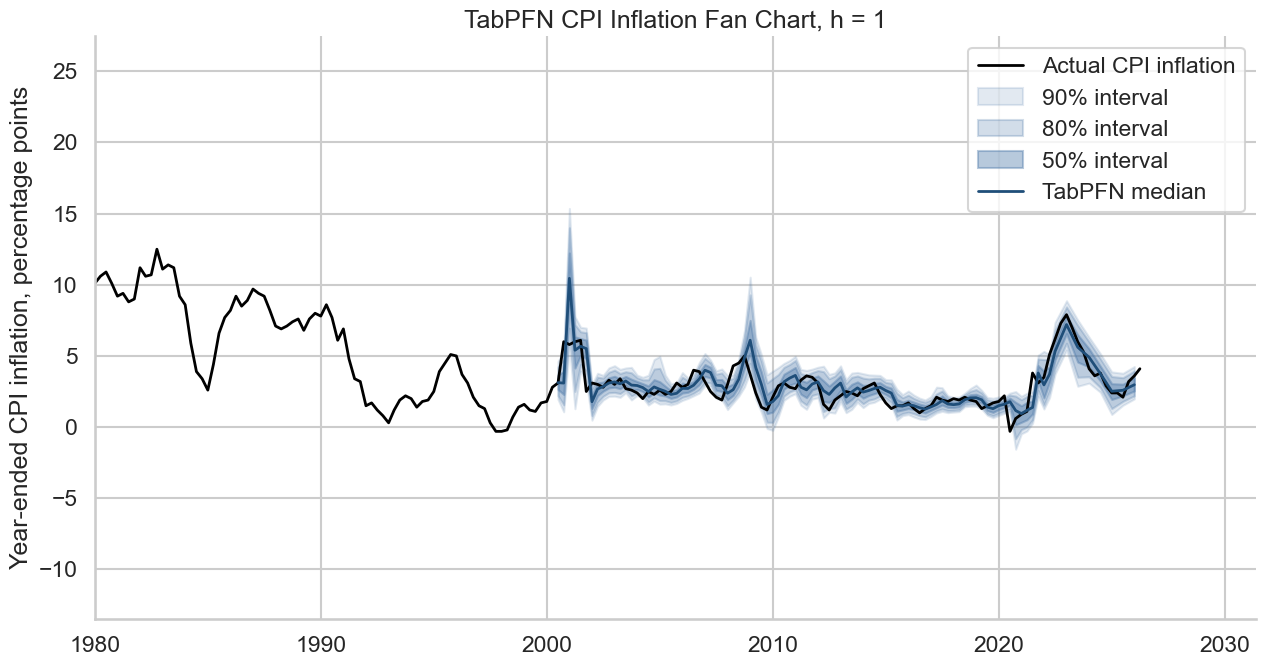

In [8]:
horizon = 1
plot_df = horizon_frame(horizon)
actual_df = actual_frame()

fig, ax = plt.subplots(figsize=(13, 7))
ax.plot(actual_df["date"], actual_df["actual_value"], color="black", linewidth=2.0, label="Actual CPI inflation")
ax.fill_between(plot_df["date"], plot_df["q05"], plot_df["q95"], color="#4C78A8", alpha=0.16, label="90% interval")
ax.fill_between(plot_df["date"], plot_df["q10"], plot_df["q90"], color="#4C78A8", alpha=0.25, label="80% interval")
ax.fill_between(plot_df["date"], plot_df["q25"], plot_df["q75"], color="#4C78A8", alpha=0.40, label="50% interval")
ax.plot(plot_df["date"], plot_df["median_forecast"], color="#1F4E79", linewidth=2.0, label="TabPFN median")
ax.set_title(f"TabPFN CPI Inflation Fan Chart, h = {horizon}")
ax.set_ylabel("Year-ended CPI inflation, percentage points")
apply_time_axis(ax)
ax.legend(loc="best")
savefig("tabpfn_cpi_fan_h1.png")
plt.show()

## 8. RBA vs TabPFN Forecast Paths

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_rba_vs_tabpfn_h1.png


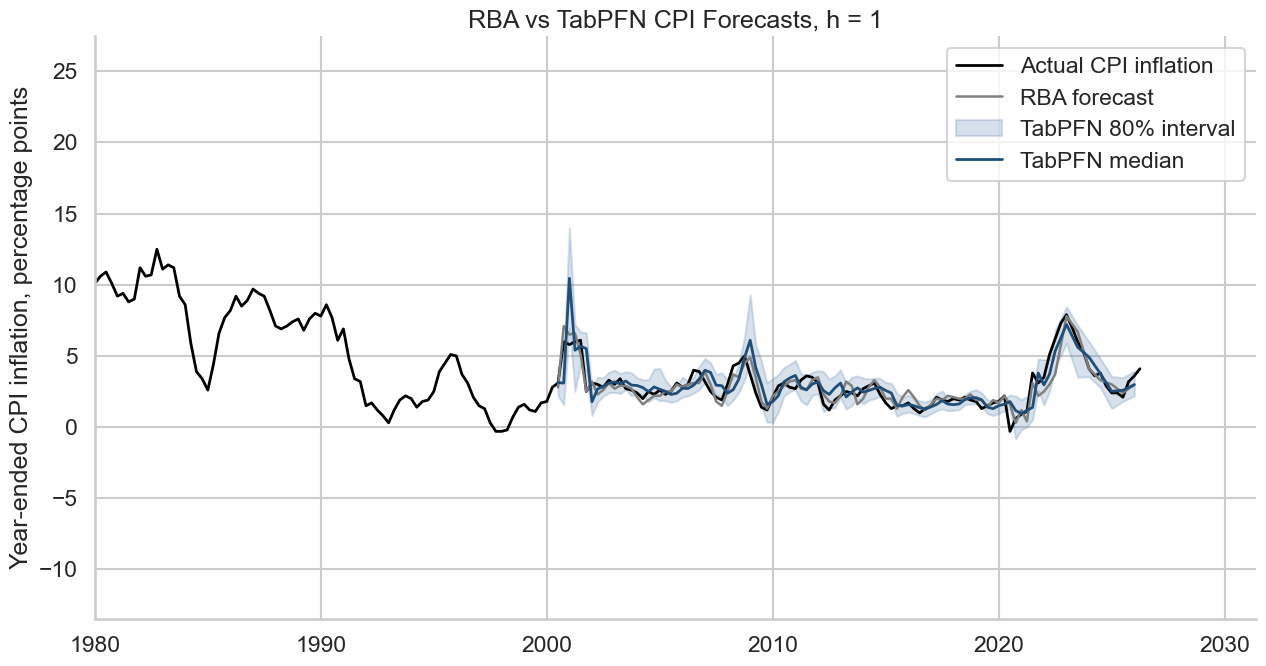

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_rba_vs_tabpfn_h4.png


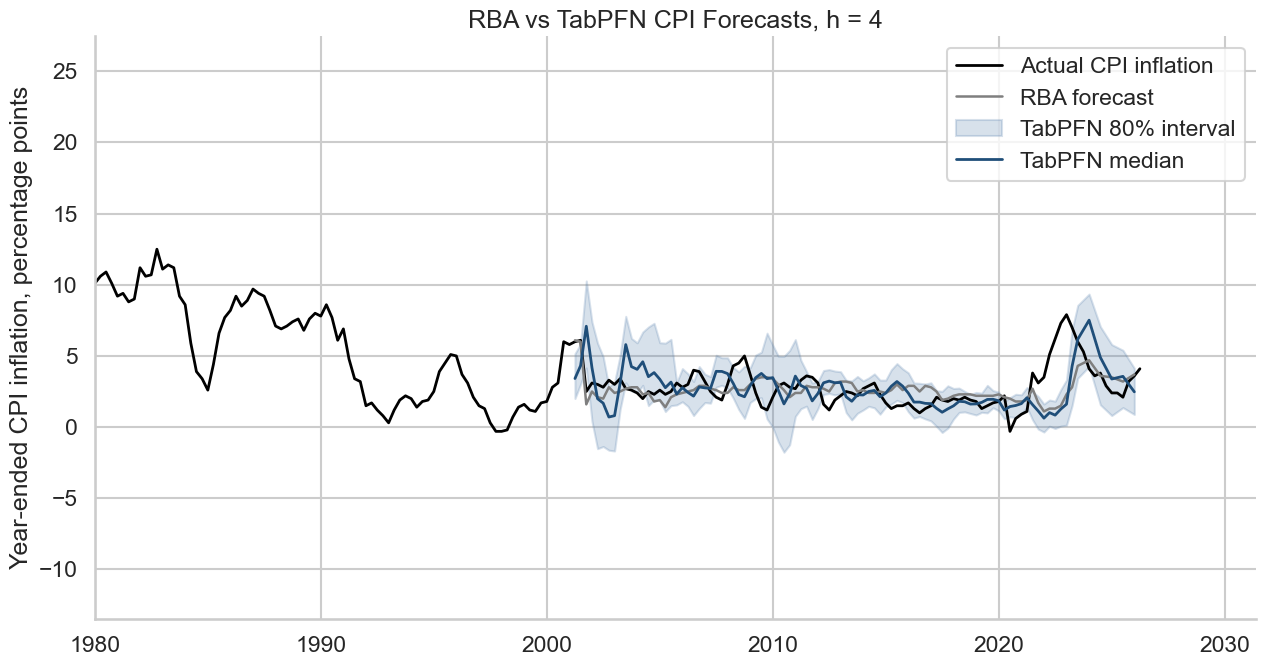

In [9]:
for horizon in [1, 4]:
    plot_df = horizon_frame(horizon)
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.plot(actual_df["date"], actual_df["actual_value"], color="black", linewidth=2.0, label="Actual CPI inflation")
    ax.plot(plot_df["date"], plot_df["rba_forecast"], color="#7F7F7F", linewidth=1.8, label="RBA forecast")
    ax.fill_between(plot_df["date"], plot_df["q10"], plot_df["q90"], color="#4C78A8", alpha=0.22, label="TabPFN 80% interval")
    ax.plot(plot_df["date"], plot_df["median_forecast"], color="#1F4E79", linewidth=2.0, label="TabPFN median")
    ax.set_title(f"RBA vs TabPFN CPI Forecasts, h = {horizon}")
    ax.set_ylabel("Year-ended CPI inflation, percentage points")
    apply_time_axis(ax)
    ax.legend(loc="best")
    savefig(f"tabpfn_cpi_rba_vs_tabpfn_h{horizon}.png")
    plt.show()

## 9. Predictive Quantile Snapshots

These are posterior-like predictive distributions: useful uncertainty summaries, not structural Bayesian posteriors.

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_quantile_snapshots.png


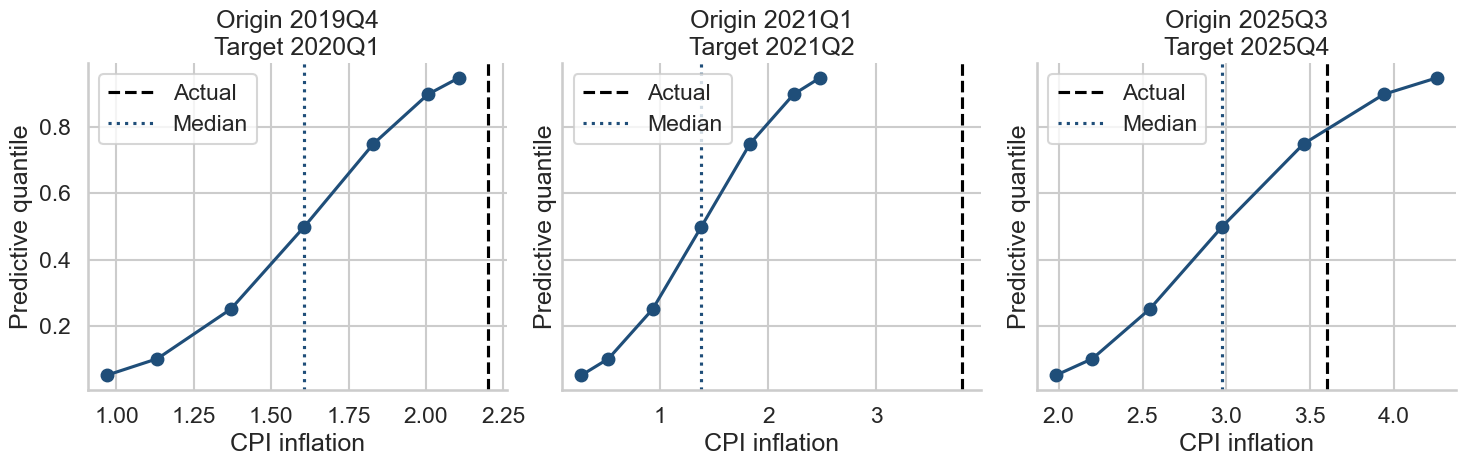

In [10]:
snapshot_horizon = 1
snap_df = valid_forecasts.filter(pl.col("horizon") == snapshot_horizon).sort("forecast_qtr")
pre_covid = snap_df.filter(pl.col("forecast_qtr") < "2020Q1").tail(1)
inflation_surge = snap_df.filter((pl.col("forecast_qtr") >= "2021Q1") & (pl.col("forecast_qtr") <= "2023Q4")).head(1)
latest = snap_df.tail(1)
snapshots = pl.concat([pre_covid, inflation_surge, latest]).unique(subset=["forecast_qtr", "horizon"]).sort("forecast_qtr")

q_cols = [f"q{int(q * 100):02d}" for q in QUANTILES]
fig, axes = plt.subplots(1, snapshots.height, figsize=(5 * snapshots.height, 5), sharey=True)
if snapshots.height == 1:
    axes = [axes]
for ax, row in zip(axes, snapshots.iter_rows(named=True), strict=False):
    x_values = [row[col] for col in q_cols]
    ax.plot(x_values, QUANTILES, marker="o", color="#1F4E79")
    ax.axvline(row["actual_value"], color="black", linestyle="--", label="Actual")
    ax.axvline(row["median_forecast"], color="#1F4E79", linestyle=":", label="Median")
    ax.set_title(f"Origin {row['forecast_qtr']}\nTarget {row['year_qtr']}")
    ax.set_xlabel("CPI inflation")
    ax.set_ylabel("Predictive quantile")
    ax.legend(loc="best")
savefig("tabpfn_cpi_quantile_snapshots.png")
plt.show()

## 10. Calibration

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_interval_coverage.png


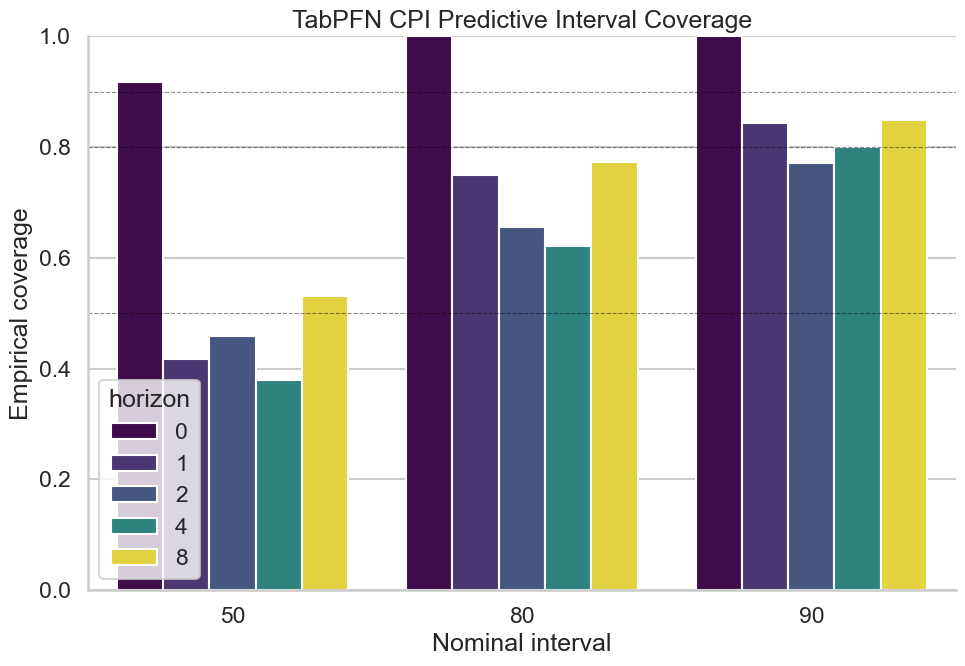

In [11]:
cal = coverage.with_columns(
    pl.col("interval").cast(pl.Float64).truediv(100).alias("nominal")
).to_pandas()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=cal, x="interval", y="coverage", hue="horizon", ax=ax, palette="viridis")
for nominal in [0.5, 0.8, 0.9]:
    ax.axhline(nominal, color="black", linewidth=0.8, linestyle="--", alpha=0.45)
ax.set_title("TabPFN CPI Predictive Interval Coverage")
ax.set_xlabel("Nominal interval")
ax.set_ylabel("Empirical coverage")
ax.set_ylim(0, 1)
savefig("tabpfn_cpi_interval_coverage.png")
plt.show()

## 11. Error vs Predictive Uncertainty

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_error_vs_uncertainty.png


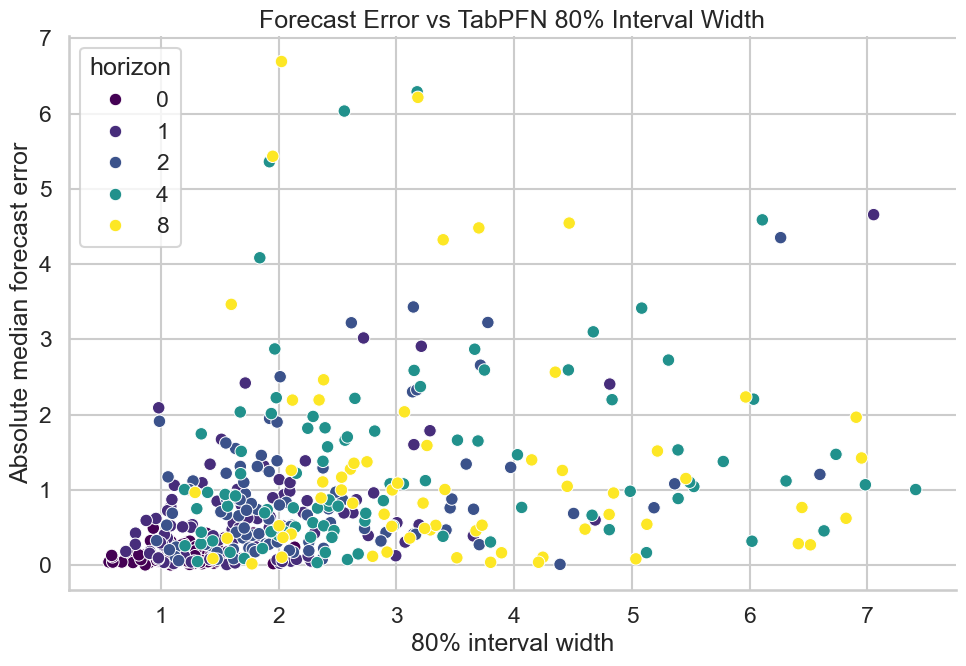

In [12]:
scatter_df = valid_forecasts.with_columns(
    pl.col("median_error").abs().alias("abs_median_error"),
    (pl.col("q90") - pl.col("q10")).alias("width_80"),
).to_pandas()

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=scatter_df, x="width_80", y="abs_median_error", hue="horizon", palette="viridis", ax=ax)
ax.set_title("Forecast Error vs TabPFN 80% Interval Width")
ax.set_xlabel("80% interval width")
ax.set_ylabel("Absolute median forecast error")
savefig("tabpfn_cpi_error_vs_uncertainty.png")
plt.show()

## 12. Interval Misses Over Time

Saved /Users/joepaul/Documents/PhD/explorations/RBA/Python/outputs/figures/tabpfn_cpi_interval_misses_h1.png


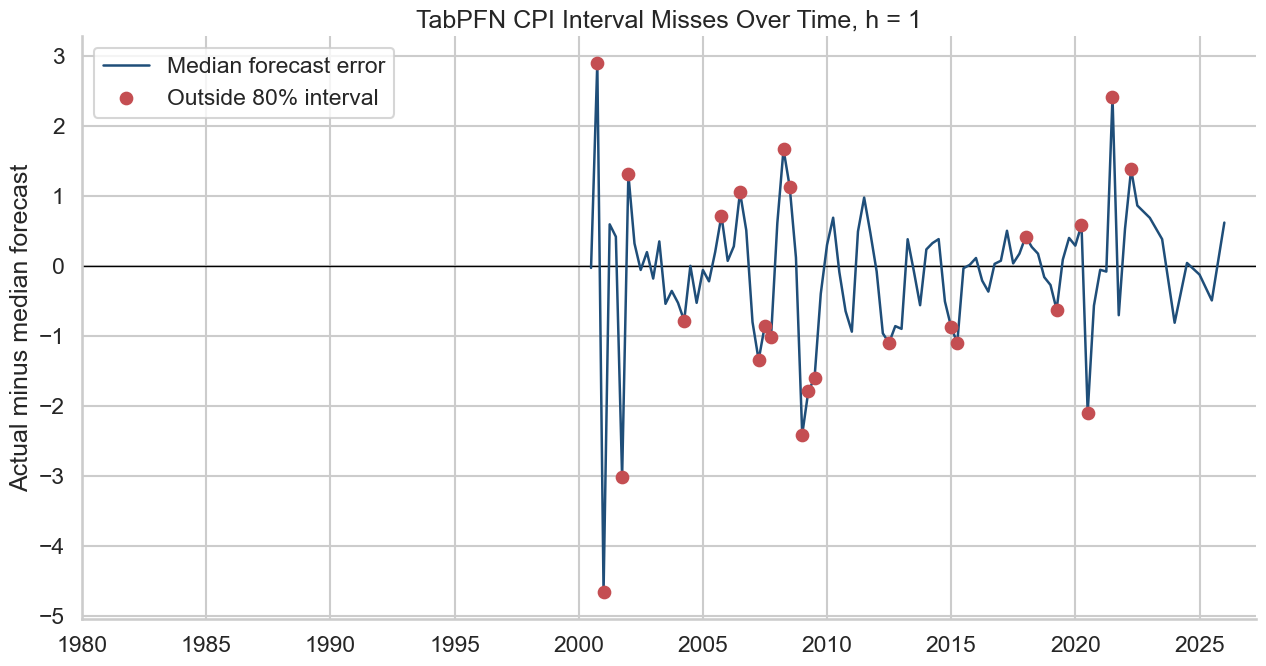

In [13]:
miss_horizon = 1
miss_df = (
    valid_forecasts.filter(pl.col("horizon") == miss_horizon)
    .with_columns(
        ((pl.col("actual_value") < pl.col("q10")) | (pl.col("actual_value") > pl.col("q90"))).alias("miss_80"),
    )
    .sort("year_qtr")
    .to_pandas()
)
miss_df["date"] = quarter_to_timestamp(miss_df["year_qtr"])

fig, ax = plt.subplots(figsize=(13, 7))
ax.axhline(0, color="black", linewidth=1.0)
ax.plot(miss_df["date"], miss_df["median_error"], color="#1F4E79", linewidth=1.8, label="Median forecast error")
misses = miss_df[miss_df["miss_80"]]
ax.scatter(misses["date"], misses["median_error"], color="#C44E52", s=70, label="Outside 80% interval", zorder=5)
ax.set_title(f"TabPFN CPI Interval Misses Over Time, h = {miss_horizon}")
ax.set_ylabel("Actual minus median forecast")
apply_time_axis(ax)
ax.legend(loc="best")
savefig("tabpfn_cpi_interval_misses_h1.png")
plt.show()

## 13. Optional CPI Benchmark Overlay

If `ml_results.rds` exists, this cell compares TabPFN with the existing CPI AR(1) rows. Keep the comparison visual and descriptive for this first pass.

In [14]:
if ml_results is None:
    print("No existing ml_results.rds found; skipping AR(1) overlay.")
else:
    horizon = 1
    ar1 = (
        ml_results.filter(
            (pl.col("target") == TARGET)
            & (pl.col("horizon") == horizon)
            & (pl.col("model") == "AR(1)")
        )
        .select("year_qtr", "ml_forecast")
        .sort("year_qtr")
        .to_pandas()
    )
    ar1["date"] = quarter_to_timestamp(ar1["year_qtr"])
    plot_df = horizon_frame(horizon)

    fig, ax = plt.subplots(figsize=(13, 7))
    ax.plot(actual_df["date"], actual_df["actual_value"], color="black", linewidth=2.0, label="Actual CPI inflation")
    ax.plot(ar1["date"], ar1["ml_forecast"], color="#7F7F7F", linewidth=1.8, label="AR(1)")
    ax.plot(plot_df["date"], plot_df["median_forecast"], color="#1F4E79", linewidth=2.0, label="TabPFN median")
    ax.fill_between(plot_df["date"], plot_df["q10"], plot_df["q90"], color="#4C78A8", alpha=0.20, label="TabPFN 80% interval")
    ax.set_title(f"CPI Benchmark Overlay, h = {horizon}")
    ax.set_ylabel("Year-ended CPI inflation, percentage points")
    apply_time_axis(ax)
    ax.legend(loc="best")
    savefig("tabpfn_cpi_ar1_overlay_h1.png")
    plt.show()

No existing ml_results.rds found; skipping AR(1) overlay.
